In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

Device      : cuda
Model path  : /content/drive/MyDrive/CVPR/gtsrbX_finetuned.pth
Output dir  : /content/drive/MyDrive/CVPR/Output

Loading fine-tuned model...
✅ Fine-tuned model loaded successfully. Ready for inference.

Test samples: 12630

  PART A — Overall Strategy Benchmark  (mixed weather)

  Strategy: baseline
    Accuracy          : 83.98%
    Latency median    : 11.644 ms
    Latency std       : 3.167 ms
    Latency mean      : 12.444 ms
    Latency p95       : 18.683 ms
    Latency p99       : 23.482 ms
    Latency range     : 8.137 – 68.681 ms
    Peak VRAM         : 262.6 MB

  Strategy: clahe
    Accuracy          : 92.19%
    Latency median    : 15.765 ms
    Latency std       : 6.826 ms
    Latency mean      : 18.835 ms
    Latency p95       : 33.254 ms
    Latency p99       : 42.439 ms
    Latency range     : 11.851 – 71.810 ms
    Peak VRAM         : 262.6 MB

  Strategy: gamma
    Accuracy          : 82.53%
    Latency median    : 15.777 ms
    Latency std       : 6.

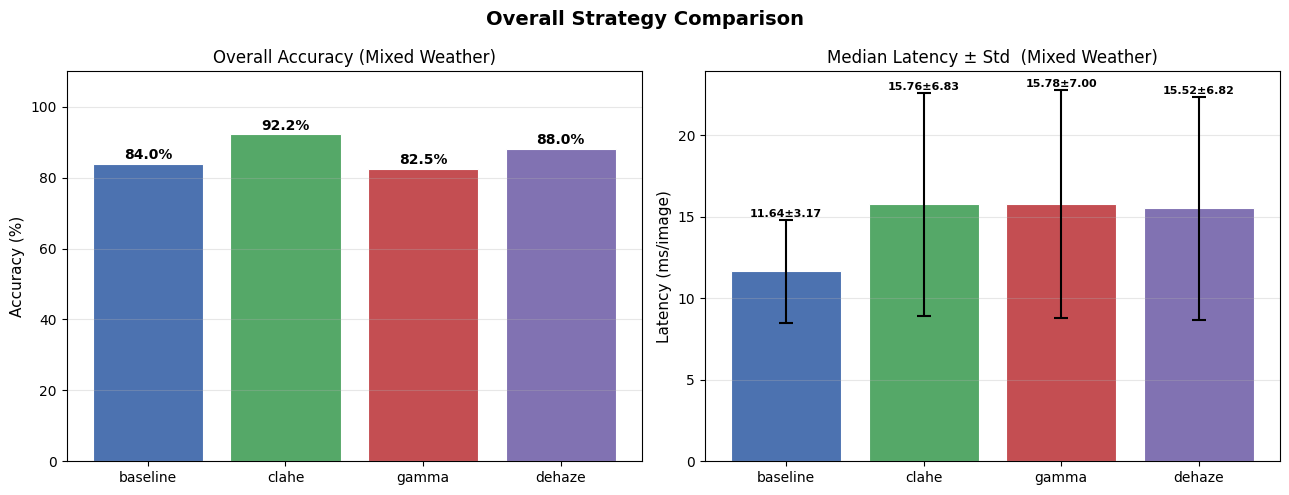

Saved → /content/drive/MyDrive/CVPR/Output/plots/overall_accuracy_latency.png


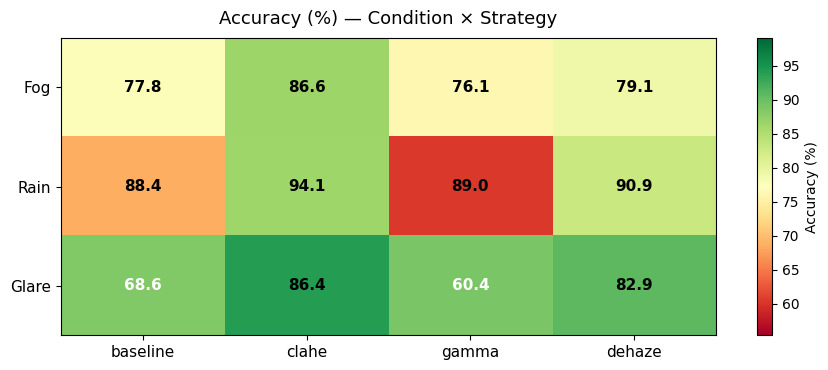

Saved → /content/drive/MyDrive/CVPR/Output/plots/condition_accuracy_heatmap.png


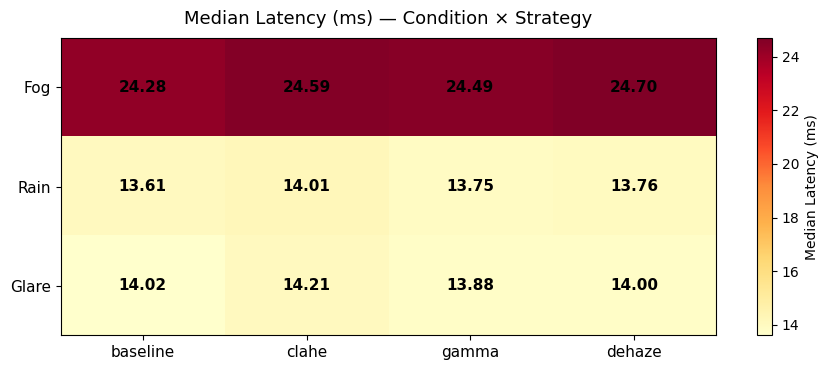

Saved → /content/drive/MyDrive/CVPR/Output/plots/condition_latency_heatmap.png


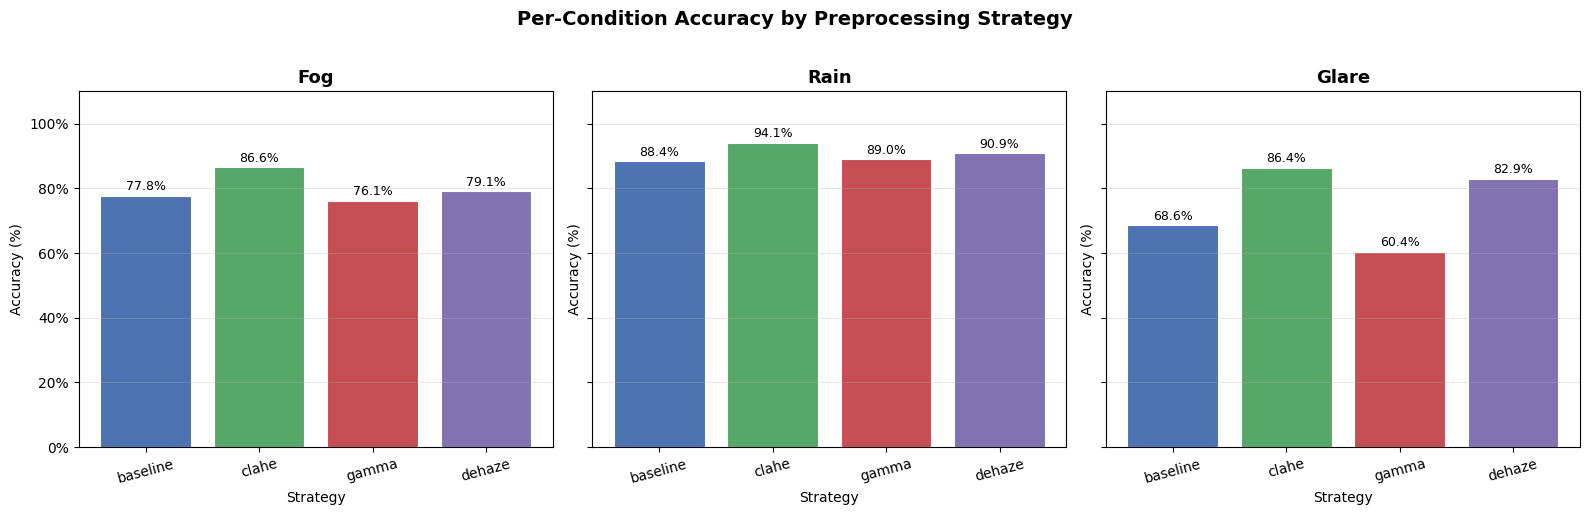

Saved → /content/drive/MyDrive/CVPR/Output/plots/condition_accuracy_bars.png


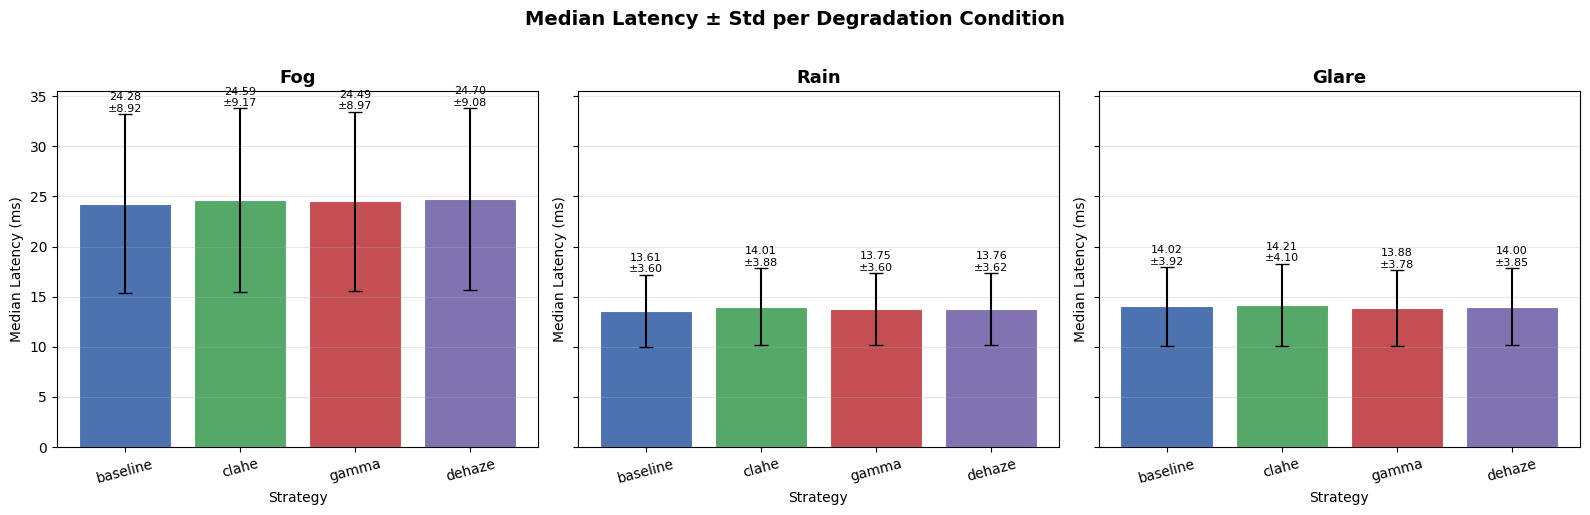

Saved → /content/drive/MyDrive/CVPR/Output/plots/condition_latency_bars.png


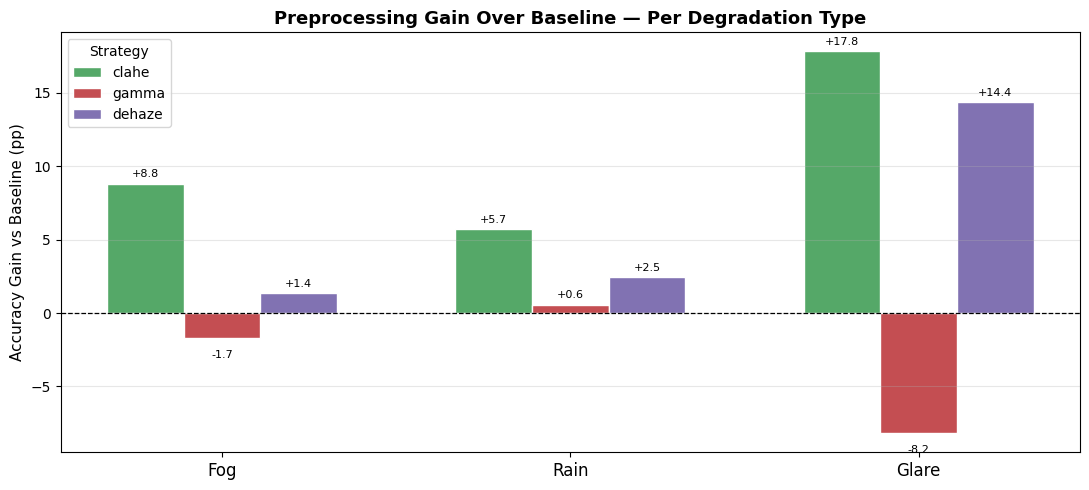

Saved → /content/drive/MyDrive/CVPR/Output/plots/gain_over_baseline.png



/tmp/ipykernel_1322/3351950113.py:553: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


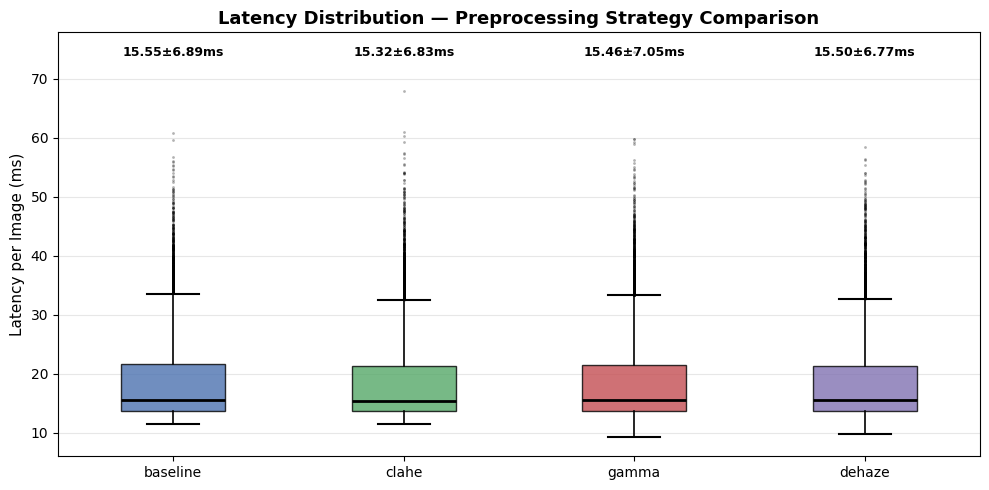

Saved → /content/drive/MyDrive/CVPR/Output/plots/latency_boxplot.png

  FINAL SUMMARY

── Overall (mixed weather) — Median ± Std Latency ──
  baseline  |  acc= 83.98%  |  median=11.644ms  |  std=3.167ms  |  p95=18.683ms  |  p99=23.482ms  |  VRAM=262.6MB
     clahe  |  acc= 92.19%  |  median=15.765ms  |  std=6.826ms  |  p95=33.254ms  |  p99=42.439ms  |  VRAM=262.6MB
     gamma  |  acc= 82.53%  |  median=15.777ms  |  std=6.998ms  |  p95=33.826ms  |  p99=43.017ms  |  VRAM=262.6MB
    dehaze  |  acc= 88.03%  |  median=15.519ms  |  std=6.825ms  |  p95=32.783ms  |  p99=41.943ms  |  VRAM=262.6MB

── Best accuracy per condition ──
    Fog:     clahe  →  86.58%
   Rain:     clahe  →  94.13%
  Glare:     clahe  →  86.41%

── Best (lowest) latency per condition ──
    Fog:  baseline  →  median=24.278ms  ±  8.916ms
   Rain:  baseline  →  median=13.609ms  ±  3.600ms
  Glare:     gamma  →  median=13.884ms  ±  3.780ms

── Full results table (per-condition) ──
condition strategy  accuracy_pct  median_

In [ ]:
# ============================================================
# FULL PIPELINE — LOAD FINE-TUNED MODEL + LATENCY BENCHMARK
# (Median ± Std, Accuracy, VRAM) — Overall + Per-Condition
# GOOGLE COLAB VERSION
# ============================================================

# ------------------------------------------------------------------
# STEP 0 — Mount Google Drive & install dependencies
# ------------------------------------------------------------------




import os
import cv2
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torchvision.models as models

from torch.amp import autocast
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ==================================================================
# 0. PATHS & CONFIG  — adjust these to match your Drive structure
# ==================================================================
DRIVE_ROOT        = "/content/drive/MyDrive/CVPR"      # ← change if needed
MODEL_PATH         = os.path.join(DRIVE_ROOT, "gtsrbX_finetuned.pth")
TEST_CSV           = os.path.join(DRIVE_ROOT, "GTSRB", "Test.csv")
BASE_PATH          = os.path.join(DRIVE_ROOT, "GTSRB")
OUTPUT_DIR         = os.path.join(DRIVE_ROOT, "Output")
RESULTS_CSV        = os.path.join(OUTPUT_DIR, "latency_results.csv")
COND_CSV           = os.path.join(OUTPUT_DIR, "per_condition_latency_results.csv")
PLOTS_DIR          = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 1          # per-image latency — must be 1 for meaningful per-sample timing
AMP_ENABLED = torch.cuda.is_available()
WARMUP_RUNS = 20         # GPU warmup iterations before timing starts
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device      : {device}")
print(f"Model path  : {MODEL_PATH}")
print(f"Output dir  : {OUTPUT_DIR}\n")

if device.type == "cpu":
    print("⚠️  WARNING: No GPU detected. Latency timings will be CPU-bound and")
    print("    much slower/noisier than GPU timings. Go to Runtime → Change")
    print("    runtime type → GPU before running a real benchmark.\n")

# ==================================================================
# 1. MODEL DEFINITION  (must match checkpoint architecture exactly)
# ==================================================================
class GTSRBModel(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.rn50    = models.resnet50(weights=None)
        in_features  = 1000
        self.dropout = nn.Dropout(0.5)
        self.fl1     = nn.Linear(in_features, 256)
        self.relu    = nn.ReLU()
        self.fl2     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.rn50(x)
        x = self.dropout(x)
        x = self.relu(self.fl1(x))
        x = self.fl2(x)
        return x

# ==================================================================
# 2. LOAD FINE-TUNED MODEL  (no training — direct checkpoint load)
# ==================================================================
print("Loading fine-tuned model...")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model checkpoint not found at: {MODEL_PATH}\n"
        f"Make sure you uploaded it to your Google Drive and the path above is correct."
    )

model = GTSRBModel().to(device)

checkpoint = torch.load(MODEL_PATH, map_location=device)
# Handle both plain state_dict and full metadata checkpoints
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    saved_acc = checkpoint.get("val_acc", None)
    if saved_acc:
        print(f"  Checkpoint val_acc : {saved_acc*100:.2f}%")
else:
    model.load_state_dict(checkpoint, strict=False)

model.eval()
print("✅ Fine-tuned model loaded successfully. Ready for inference.\n")

# ==================================================================
# 3. PREPROCESSING STRATEGIES
# ==================================================================
def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

def gamma_correction(image, gamma=1.5):
    table = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                      for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

def simple_dehaze(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

def preprocess_image(image, strategy="baseline"):
    if strategy == "clahe":  return apply_clahe(image)
    if strategy == "gamma":  return gamma_correction(image)
    if strategy == "dehaze": return simple_dehaze(image)
    return image  # baseline

# ==================================================================
# 4. CONDITION SIMULATORS  (deterministic p=1.0 for clean benchmarking)
# ==================================================================
CONDITION_TRANSFORMS = {
    "fog":   A.Compose([A.RandomFog(fog_coef_range=(0.3, 0.3), alpha_coef=0.1, p=1.0)]),
    "rain":  A.Compose([A.RandomRain(brightness_coefficient=0.9, drop_length=5, p=1.0)]),
    "glare": A.Compose([A.RandomSunFlare(
                flare_roi=(0, 0, 1, 0.5), angle_range=(0, 1),
                num_flare_circles_range=(6, 10), src_radius=200, p=1.0)]),
}

eval_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# ==================================================================
# 5. DATASETS
# ==================================================================
class OverallDataset(Dataset):
    """Mixed weather dataset — fog/rain/glare applied with 70% probability."""
    def __init__(self, csv_df, base_path, strategy, transform):
        self.df        = csv_df
        self.base_path = base_path
        self.strategy  = strategy
        self.transform = transform
        self.weather   = A.OneOf([
            A.RandomFog(fog_coef_range=(0.2, 0.4), alpha_coef=0.1, p=1.0),
            A.RandomRain(brightness_coefficient=0.9, drop_length=5, p=1.0),
            A.RandomSunFlare(flare_roi=(0, 0, 1, 0.5),
                             num_flare_circles_range=(4, 8), src_radius=150, p=1.0),
        ], p=0.7)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.normpath(os.path.join(self.base_path, row["Path"]))
        label    = int(row["ClassId"])
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Cannot load: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.weather(image=img)["image"]
        img = preprocess_image(img, self.strategy)
        img = self.transform(image=img)["image"]
        return img, label


class ConditionDataset(Dataset):
    """Single fixed degradation (fog/rain/glare) + single preprocessing strategy."""
    def __init__(self, csv_df, base_path, condition_name, strategy, transform):
        self.df        = csv_df
        self.base_path = base_path
        self.cond_tfm  = CONDITION_TRANSFORMS[condition_name]
        self.strategy  = strategy
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.normpath(os.path.join(self.base_path, row["Path"]))
        label    = int(row["ClassId"])
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Cannot load: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.cond_tfm(image=img)["image"]
        img = preprocess_image(img, self.strategy)
        img = self.transform(image=img)["image"]
        return img, label

# ==================================================================
# 6. CORE BENCHMARK  — per-image latency + accuracy + VRAM
#    Returns median, std, mean, p95, p99 (not just average)
# ==================================================================
def benchmark(dataset, model, device, warmup=WARMUP_RUNS):
    """
    Runs inference one image at a time (batch_size=1).
    Records wall-clock time per image after GPU warmup.
    Returns: preds, labels, per_image_latencies_ms, peak_vram_mb
    """
    loader = DataLoader(dataset, batch_size=1, shuffle=False,
                        num_workers=2, pin_memory=False)

    all_preds, all_labels, latencies = [], [], []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

        # ── GPU warmup (prevents cold-start bias in first N timings) ──
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
        for _ in range(warmup):
            with torch.no_grad():
                with autocast('cuda', enabled=AMP_ENABLED):
                    _ = model(dummy)
        torch.cuda.synchronize(device)
        del dummy
        torch.cuda.reset_peak_memory_stats(device)  # reset after warmup

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            if torch.cuda.is_available():
                torch.cuda.synchronize(device)   # sync before timing

            t_start = time.perf_counter()

            with autocast('cuda', enabled=AMP_ENABLED):
                outputs = model(images)

            if torch.cuda.is_available():
                torch.cuda.synchronize(device)   # sync after timing

            t_end = time.perf_counter()

            latencies.append((t_end - t_start) * 1000)   # ms
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    peak_vram = (torch.cuda.max_memory_allocated(device) / 1024**2
                 if torch.cuda.is_available() else None)

    return (np.array(all_preds),
            np.array(all_labels),
            np.array(latencies),
            peak_vram)


def latency_stats(latencies):
    """Compute median, std, mean, p95, p99 from per-image latency array (ms)."""
    return {
        "median_ms": float(np.median(latencies)),
        "std_ms":    float(np.std(latencies)),
        "mean_ms":   float(np.mean(latencies)),
        "p95_ms":    float(np.percentile(latencies, 95)),
        "p99_ms":    float(np.percentile(latencies, 99)),
        "min_ms":    float(np.min(latencies)),
        "max_ms":    float(np.max(latencies)),
        "n_samples": len(latencies),
    }

# ==================================================================
# 7. LOAD TEST DATA
# ==================================================================
if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(
        f"Test CSV not found at: {TEST_CSV}\n"
        f"Make sure your GTSRB dataset is uploaded to Google Drive."
    )

test_df = pd.read_csv(TEST_CSV)
print(f"Test samples: {len(test_df)}\n")

strategies = ["baseline", "clahe", "gamma", "dehaze"]
conditions = ["fog", "rain", "glare"]

strategy_colors = {
    "baseline": "#4C72B0", "clahe":  "#55A868",
    "gamma":    "#C44E52", "dehaze": "#8172B2",
}

# ==================================================================
# 8. PART A — OVERALL BENCHMARK  (mixed weather, 70% probability)
# ==================================================================
print("=" * 65)
print("  PART A — Overall Strategy Benchmark  (mixed weather)")
print("=" * 65)

overall_rows = []

for strategy in strategies:
    print(f"\n  Strategy: {strategy}")
    ds = OverallDataset(test_df, BASE_PATH, strategy, eval_transforms)
    preds, labels, latencies, peak_vram = benchmark(ds, model, device)

    acc   = accuracy_score(labels, preds) * 100
    stats = latency_stats(latencies)
    vram_str = f"{peak_vram:.1f} MB" if peak_vram is not None else "N/A"

    print(f"    Accuracy          : {acc:.2f}%")
    print(f"    Latency median    : {stats['median_ms']:.3f} ms")
    print(f"    Latency std       : {stats['std_ms']:.3f} ms")
    print(f"    Latency mean      : {stats['mean_ms']:.3f} ms")
    print(f"    Latency p95       : {stats['p95_ms']:.3f} ms")
    print(f"    Latency p99       : {stats['p99_ms']:.3f} ms")
    print(f"    Latency range     : {stats['min_ms']:.3f} – {stats['max_ms']:.3f} ms")
    print(f"    Peak VRAM         : {vram_str}")

    overall_rows.append({
        "strategy":     strategy,
        "accuracy_pct": acc,
        "peak_vram_mb": peak_vram,
        **{f"overall_{k}": v for k, v in stats.items()},
    })

overall_df = pd.DataFrame(overall_rows)
overall_df.to_csv(RESULTS_CSV, index=False)
print(f"\nOverall results saved → {RESULTS_CSV}")

# ==================================================================
# 9. PART B — PER-CONDITION BENCHMARK  (fog | rain | glare, isolated)
# ==================================================================
print("\n" + "=" * 65)
print("  PART B — Per-Condition Latency Breakdown")
print("=" * 65)

cond_rows = []

for condition in conditions:
    print(f"\n  ── CONDITION: {condition.upper()} ──")
    for strategy in strategies:
        ds = ConditionDataset(test_df, BASE_PATH, condition, strategy, eval_transforms)
        preds, labels, latencies, peak_vram = benchmark(ds, model, device)

        acc   = accuracy_score(labels, preds) * 100
        stats = latency_stats(latencies)
        vram_str = f"{peak_vram:.1f} MB" if peak_vram is not None else "N/A"

        print(f"    [{strategy:>8}]  "
              f"acc={acc:6.2f}%  "
              f"median={stats['median_ms']:.3f}ms  "
              f"std={stats['std_ms']:.3f}ms  "
              f"p95={stats['p95_ms']:.3f}ms  "
              f"VRAM={vram_str}")

        cond_rows.append({
            "condition":    condition,
            "strategy":     strategy,
            "accuracy_pct": acc,
            "peak_vram_mb": peak_vram,
            **stats,
        })

cond_df = pd.DataFrame(cond_rows)
cond_df.to_csv(COND_CSV, index=False)
print(f"\nPer-condition results saved → {COND_CSV}")

# ==================================================================
# 10. PLOTS
# ==================================================================

# ── Plot 1: Overall accuracy + Median latency ± std ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars = ax1.bar(overall_df["strategy"], overall_df["accuracy_pct"],
               color=[strategy_colors[s] for s in overall_df["strategy"]],
               edgecolor="white", linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5,
             f"{h:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_ylabel("Accuracy (%)", fontsize=11)
ax1.set_title("Overall Accuracy (Mixed Weather)", fontsize=12)
ax1.set_ylim(0, 110); ax1.grid(axis="y", alpha=0.3)

ax2.bar(overall_df["strategy"],
        overall_df["overall_median_ms"],
        yerr=overall_df["overall_std_ms"],
        color=[strategy_colors[s] for s in overall_df["strategy"]],
        edgecolor="white", linewidth=0.8,
        error_kw=dict(elinewidth=1.5, capsize=5, capthick=1.5, ecolor="black"))
for i, row in overall_df.iterrows():
    ax2.text(i, row["overall_median_ms"] + row["overall_std_ms"] + 0.05,
             f"{row['overall_median_ms']:.2f}±{row['overall_std_ms']:.2f}",
             ha="center", va="bottom", fontsize=8, fontweight="bold")
ax2.set_ylabel("Latency (ms/image)", fontsize=11)
ax2.set_title("Median Latency ± Std  (Mixed Weather)", fontsize=12)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Overall Strategy Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
p1 = os.path.join(PLOTS_DIR, "overall_accuracy_latency.png")
plt.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {p1}")

# ── Plot 2: Per-condition accuracy heatmap ────────────────────────
pivot_acc = cond_df.pivot(index="condition", columns="strategy",
                           values="accuracy_pct")[strategies]
fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(pivot_acc.values, cmap="RdYlGn", aspect="auto",
               vmin=max(0, pivot_acc.values.min()-5),
               vmax=min(100, pivot_acc.values.max()+5))
ax.set_xticks(range(len(strategies))); ax.set_xticklabels(strategies, fontsize=11)
ax.set_yticks(range(len(conditions)))
ax.set_yticklabels([c.capitalize() for c in conditions], fontsize=11)
ax.set_title("Accuracy (%) — Condition × Strategy", fontsize=13, pad=10)
for i, cond in enumerate(conditions):
    for j, strat in enumerate(strategies):
        val = pivot_acc.loc[cond, strat]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white" if val < pivot_acc.values.min()+10 else "black")
plt.colorbar(im, ax=ax, label="Accuracy (%)")
plt.tight_layout()
p2 = os.path.join(PLOTS_DIR, "condition_accuracy_heatmap.png")
plt.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {p2}")

# ── Plot 3: Per-condition latency heatmap (median) ────────────────
pivot_lat = cond_df.pivot(index="condition", columns="strategy",
                           values="median_ms")[strategies]
fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(pivot_lat.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(strategies))); ax.set_xticklabels(strategies, fontsize=11)
ax.set_yticks(range(len(conditions)))
ax.set_yticklabels([c.capitalize() for c in conditions], fontsize=11)
ax.set_title("Median Latency (ms) — Condition × Strategy", fontsize=13, pad=10)
for i, cond in enumerate(conditions):
    for j, strat in enumerate(strategies):
        val = pivot_lat.loc[cond, strat]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=11, fontweight="bold", color="black")
plt.colorbar(im, ax=ax, label="Median Latency (ms)")
plt.tight_layout()
p3 = os.path.join(PLOTS_DIR, "condition_latency_heatmap.png")
plt.savefig(p3, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {p3}")

# ── Plot 4: Grouped bars — accuracy per condition ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, cond in zip(axes, conditions):
    sub  = cond_df[cond_df["condition"] == cond]
    bars = ax.bar(sub["strategy"], sub["accuracy_pct"],
                  color=[strategy_colors[s] for s in sub["strategy"]],
                  edgecolor="white", linewidth=0.8)
    ax.set_title(cond.capitalize(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Strategy", fontsize=10)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))
    ax.set_ylabel("Accuracy (%)", fontsize=10)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
fig.suptitle("Per-Condition Accuracy by Preprocessing Strategy",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
p4 = os.path.join(PLOTS_DIR, "condition_accuracy_bars.png")
plt.savefig(p4, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {p4}")

# ── Plot 5: Grouped bars — median latency ± std per condition ─────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, cond in zip(axes, conditions):
    sub = cond_df[cond_df["condition"] == cond]
    ax.bar(sub["strategy"], sub["median_ms"],
           yerr=sub["std_ms"],
           color=[strategy_colors[s] for s in sub["strategy"]],
           edgecolor="white", linewidth=0.8,
           error_kw=dict(elinewidth=1.5, capsize=5, ecolor="black"))
    ax.set_title(cond.capitalize(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Strategy", fontsize=10)
    ax.set_ylabel("Median Latency (ms)", fontsize=10)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    for i, row in sub.iterrows():
        ax.text(strategies.index(row["strategy"]),
                row["median_ms"] + row["std_ms"] + 0.02,
                f"{row['median_ms']:.2f}\n±{row['std_ms']:.2f}",
                ha="center", va="bottom", fontsize=8)
fig.suptitle("Median Latency ± Std per Degradation Condition",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
p5 = os.path.join(PLOTS_DIR, "condition_latency_bars.png")
plt.savefig(p5, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {p5}")

# ── Plot 6: Gain over baseline accuracy per condition ─────────────
baseline_acc = cond_df[cond_df["strategy"] == "baseline"].set_index("condition")["accuracy_pct"]
cond_df["gain"] = cond_df.apply(
    lambda r: r["accuracy_pct"] - baseline_acc[r["condition"]], axis=1)

fig, ax  = plt.subplots(figsize=(11, 5))
x        = np.arange(len(conditions))
width    = 0.22
non_base = [s for s in strategies if s != "baseline"]

for offset, strat in zip([-1, 0, 1], non_base):
    vals = [cond_df[(cond_df["condition"] == c) &
                    (cond_df["strategy"]  == strat)]["gain"].values[0]
            for c in conditions]
    bars = ax.bar(x + offset * width, vals, width, label=strat,
                  color=strategy_colors[strat], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.3 if v >= 0 else -1.5),
                f"{v:+.1f}", ha="center", va="bottom", fontsize=8)

ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in conditions], fontsize=12)
ax.set_ylabel("Accuracy Gain vs Baseline (pp)", fontsize=11)
ax.set_title("Preprocessing Gain Over Baseline — Per Degradation Type",
             fontsize=13, fontweight="bold")
ax.legend(title="Strategy", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
p6 = os.path.join(PLOTS_DIR, "gain_over_baseline.png")
plt.savefig(p6, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {p6}")

# ── Plot 7: Latency distribution box plot (overall, mixed weather) ─
print("\nCollecting raw latency arrays for box plot...")
raw_latencies = {}
for strategy in strategies:
    ds = OverallDataset(test_df, BASE_PATH, strategy, eval_transforms)
    _, _, latencies, _ = benchmark(ds, model, device)
    raw_latencies[strategy] = latencies

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [raw_latencies[s] for s in strategies],
    labels=strategies,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.5),
)
for patch, strat in zip(bp["boxes"], strategies):
    patch.set_facecolor(strategy_colors[strat])
    patch.set_alpha(0.8)
ax.set_ylabel("Latency per Image (ms)", fontsize=11)
ax.set_title("Latency Distribution — Preprocessing Strategy Comparison",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

for i, strat in enumerate(strategies, start=1):
    med = np.median(raw_latencies[strat])
    std = np.std(raw_latencies[strat])
    ax.text(i, ax.get_ylim()[1] * 0.97,
            f"{med:.2f}±{std:.2f}ms",
            ha="center", va="top", fontsize=9, fontweight="bold")

plt.tight_layout()
p7 = os.path.join(PLOTS_DIR, "latency_boxplot.png")
plt.savefig(p7, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {p7}")

# ==================================================================
# 11. FINAL SUMMARY
# ==================================================================
print("\n" + "=" * 65)
print("  FINAL SUMMARY")
print("=" * 65)

print("\n── Overall (mixed weather) — Median ± Std Latency ──")
for _, row in overall_df.iterrows():
    vram_str = f"{row['peak_vram_mb']:.1f}MB" if pd.notna(row['peak_vram_mb']) else "N/A"
    print(f"  {row['strategy']:>8}  |  "
          f"acc={row['accuracy_pct']:6.2f}%  |  "
          f"median={row['overall_median_ms']:.3f}ms  |  "
          f"std={row['overall_std_ms']:.3f}ms  |  "
          f"p95={row['overall_p95_ms']:.3f}ms  |  "
          f"p99={row['overall_p99_ms']:.3f}ms  |  "
          f"VRAM={vram_str}")

print("\n── Best accuracy per condition ──")
for cond in conditions:
    sub  = cond_df[cond_df["condition"] == cond]
    best = sub.loc[sub["accuracy_pct"].idxmax()]
    print(f"  {cond.capitalize():>5}:  {best['strategy']:>8}  →  {best['accuracy_pct']:.2f}%")

print("\n── Best (lowest) latency per condition ──")
for cond in conditions:
    sub  = cond_df[cond_df["condition"] == cond]
    best = sub.loc[sub["median_ms"].idxmin()]
    print(f"  {cond.capitalize():>5}:  "
          f"{best['strategy']:>8}  →  "
          f"median={best['median_ms']:.3f}ms  ±  {best['std_ms']:.3f}ms")

print("\n── Full results table (per-condition) ──")
print(cond_df[["condition", "strategy", "accuracy_pct", "median_ms",
               "std_ms", "p95_ms", "p99_ms", "peak_vram_mb"]].to_string(index=False))

print("\n── Output files (saved to Google Drive) ──")
for f in ["latency_results.csv", "per_condition_latency_results.csv"]:
    fp = os.path.join(OUTPUT_DIR, f)
    if os.path.exists(fp):
        print(f"  {f}  ({os.path.getsize(fp)/1024:.1f} KB)")
for f in sorted(os.listdir(PLOTS_DIR)):
    print(f"  plots/{f}")

print(f"\n✅ All results permanently saved to: {OUTPUT_DIR}")
print("   (Files persist in Google Drive — no need to re-download after session ends)")

In [ ]:
# STAGE 3.5 — LOAD FINE-TUNED MODEL FOR INFERENCE
model_path = r"/content/drive/MyDrive/CVPR/gtsrbX_finetuned.pth"
print(f"Loading inference model from: {model_path}")
model = GTSRBModel()
model = model.to(device)
checkpoint = torch.load(model_path, map_location=device)
if "model_state_dict" in checkpoint:
    checkpoint = checkpoint["model_state_dict"]
model.load_state_dict(checkpoint, strict=False)
model.eval()
print("Model loaded and ready for inference.")

Loading inference model from: /content/drive/MyDrive/CVPR/gtsrbX_finetuned.pth
Model loaded and ready for inference.


In [ ]:
# STAGE 4 — INFERENCE & EVALUATION
all_preds = []
all_labels = []

start_time = time.time()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
end_time = time.time()

accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Dataset size: {len(test_dataset)}")
print(f"Loader batches: {len(test_loader)}")
print(f"Inference complete. Processed {len(all_preds)} samples in {end_time - start_time:.2f} seconds")

avg_latency = (end_time - start_time) / len(test_dataset)
print(f"Average latency per image: {avg_latency:.4f} seconds")

Accuracy: 92.14%
Dataset size: 12630
Loader batches: 395
Inference complete. Processed 12630 samples in 6734.18 seconds
Average latency per image: 0.5332 seconds
